# Level 2: GPT-Style Decoder Architecture

## Putting It All Together!

Now we combine everything from Level 1 to build a complete GPT model:

```
Level 1 Components → GPT Block → Full GPT Model
├── Self-Attention   (how tokens interact)
├── Multi-Head       (parallel attention)
├── Positional Encoding (sequence order)
├── Layer Norm       (training stability)
└── Feed-Forward     (processing & knowledge)
```

### GPT = Generative Pre-trained Transformer

| Property | Description |
|----------|-------------|
| **Decoder-only** | No encoder, just stacked decoder blocks |
| **Causal/Autoregressive** | Each token can only see previous tokens |
| **Pre-trained** | Trained on large text corpus with next-token prediction |
| **Generative** | Can generate new text by sampling tokens |

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass

---
## 1. The GPT Architecture Overview

```
Input Tokens
     │
     ▼
┌─────────────────┐
│ Token Embedding │  (vocab_size → d_model)
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│ Position Embed  │  (learned or RoPE)
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│   GPT Block 1   │ ◄── Each block: Attention + FFN
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│   GPT Block 2   │
└────────┬────────┘
         │
        ...  (N blocks)
         │
         ▼
┌─────────────────┐
│   GPT Block N   │
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│    RMSNorm      │  (final normalization)
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│   LM Head       │  (d_model → vocab_size)
└────────┬────────┘
         │
         ▼
   Output Logits
```

---
## 2. Model Configuration

First, let's define a config class to hold all hyperparameters:

In [2]:
@dataclass
class GPTConfig:
    """Configuration for GPT model"""
    
    # Model architecture
    vocab_size: int = 50257      # GPT-2 vocabulary size
    max_seq_len: int = 1024      # Maximum sequence length
    d_model: int = 768           # Embedding dimension
    n_layers: int = 12           # Number of transformer blocks
    n_heads: int = 12            # Number of attention heads
    d_ff: int = None             # FFN hidden dim (default: 4 * d_model * 2/3)
    
    # Training
    dropout: float = 0.0         # Dropout rate (0 for inference)
    bias: bool = False           # Use bias in Linear layers (LLaMA: False)
    
    # Normalization
    norm_eps: float = 1e-5       # LayerNorm epsilon
    
    def __post_init__(self):
        # LLaMA-style d_ff calculation
        if self.d_ff is None:
            self.d_ff = int(4 * self.d_model * 2 / 3)
            # Round to multiple of 256 for efficiency
            self.d_ff = 256 * ((self.d_ff + 255) // 256)
        
        # Ensure d_model is divisible by n_heads
        assert self.d_model % self.n_heads == 0, "d_model must be divisible by n_heads"
        self.head_dim = self.d_model // self.n_heads


# Example configurations
def get_config(model_name):
    """Get predefined model configurations"""
    configs = {
        'gpt2-small': GPTConfig(d_model=768, n_layers=12, n_heads=12),    # 124M
        'gpt2-medium': GPTConfig(d_model=1024, n_layers=24, n_heads=16),  # 350M
        'gpt2-large': GPTConfig(d_model=1280, n_layers=36, n_heads=20),   # 774M
        'gpt2-xl': GPTConfig(d_model=1600, n_layers=48, n_heads=25),      # 1.5B
        'llama-7b': GPTConfig(d_model=4096, n_layers=32, n_heads=32, vocab_size=32000),
        'tiny': GPTConfig(d_model=256, n_layers=4, n_heads=4, vocab_size=1000),  # For testing
    }
    return configs[model_name]


# Show example
config = get_config('tiny')
print(f"Tiny config:")
print(f"  d_model: {config.d_model}")
print(f"  n_layers: {config.n_layers}")
print(f"  n_heads: {config.n_heads}")
print(f"  head_dim: {config.head_dim}")
print(f"  d_ff: {config.d_ff}")

Tiny config:
  d_model: 256
  n_layers: 4
  n_heads: 4
  head_dim: 64
  d_ff: 768


---
## 3. Building Blocks (From Level 1)

Let's implement all the components we learned:

In [3]:
class RMSNorm(nn.Module):
    """Root Mean Square Normalization (LLaMA style)"""
    
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))
        
    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return self.weight * (x / rms)

In [4]:
class RotaryPositionalEmbedding(nn.Module):
    """Rotary Position Embedding (RoPE) - used in LLaMA, Mistral"""
    
    def __init__(self, head_dim, max_seq_len=2048, base=10000):
        super().__init__()
        self.head_dim = head_dim
        self.max_seq_len = max_seq_len
        
        # Compute frequency bands
        inv_freq = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))
        self.register_buffer('inv_freq', inv_freq)
        
        # Precompute cos and sin
        self._build_cache(max_seq_len)
        
    def _build_cache(self, seq_len):
        positions = torch.arange(seq_len).float()
        freqs = torch.einsum('i,j->ij', positions, self.inv_freq)  # (seq_len, head_dim/2)
        freqs = torch.cat([freqs, freqs], dim=-1)  # (seq_len, head_dim)
        
        self.register_buffer('cos_cache', freqs.cos())
        self.register_buffer('sin_cache', freqs.sin())
        
    def forward(self, x, start_pos=0):
        """Apply rotary embedding to x
        
        Args:
            x: (batch, n_heads, seq_len, head_dim)
            start_pos: Starting position (for KV cache)
        """
        seq_len = x.shape[2]
        
        # Get cached cos/sin for this sequence
        cos = self.cos_cache[start_pos:start_pos + seq_len].unsqueeze(0).unsqueeze(0)
        sin = self.sin_cache[start_pos:start_pos + seq_len].unsqueeze(0).unsqueeze(0)
        
        # Rotate
        x_rotated = self._rotate_half(x)
        return x * cos + x_rotated * sin
    
    def _rotate_half(self, x):
        """Rotate half the hidden dims"""
        x1, x2 = x.chunk(2, dim=-1)
        return torch.cat([-x2, x1], dim=-1)

In [5]:
class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention with RoPE"""
    
    def __init__(self, config):
        super().__init__()
        self.n_heads = config.n_heads
        self.head_dim = config.head_dim
        self.d_model = config.d_model
        
        # QKV projection (fused for efficiency)
        self.qkv_proj = nn.Linear(config.d_model, 3 * config.d_model, bias=config.bias)
        
        # Output projection
        self.out_proj = nn.Linear(config.d_model, config.d_model, bias=config.bias)
        
        # Rotary embedding
        self.rope = RotaryPositionalEmbedding(config.head_dim, config.max_seq_len)
        
        # Dropout
        self.dropout = nn.Dropout(config.dropout)
        
        # Causal mask (registered as buffer so it moves with model)
        mask = torch.triu(torch.ones(config.max_seq_len, config.max_seq_len), diagonal=1).bool()
        self.register_buffer('causal_mask', mask)
        
    def forward(self, x, start_pos=0, kv_cache=None):
        """
        Args:
            x: (batch, seq_len, d_model)
            start_pos: Position for KV cache (inference)
            kv_cache: Tuple of (cached_k, cached_v) or None
            
        Returns:
            output: (batch, seq_len, d_model)
            new_kv_cache: Updated KV cache
        """
        batch_size, seq_len, _ = x.shape
        
        # Project to Q, K, V
        qkv = self.qkv_proj(x)  # (batch, seq_len, 3 * d_model)
        q, k, v = qkv.chunk(3, dim=-1)
        
        # Reshape for multi-head attention
        # (batch, seq_len, d_model) -> (batch, n_heads, seq_len, head_dim)
        q = q.reshape(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.reshape(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.reshape(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        
        # Apply rotary position embedding to Q and K
        q = self.rope(q, start_pos)
        k = self.rope(k, start_pos)
        
        # KV cache for efficient inference
        if kv_cache is not None:
            cached_k, cached_v = kv_cache
            k = torch.cat([cached_k, k], dim=2)
            v = torch.cat([cached_v, v], dim=2)
        
        new_kv_cache = (k, v)
        
        # Compute attention scores
        # (batch, n_heads, seq_len, head_dim) @ (batch, n_heads, head_dim, kv_len)
        # -> (batch, n_heads, seq_len, kv_len)
        scale = 1.0 / math.sqrt(self.head_dim)
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale
        
        # Apply causal mask
        kv_len = k.shape[2]
        if kv_cache is None:
            # Training: apply full causal mask
            mask = self.causal_mask[:seq_len, :seq_len]
            scores = scores.masked_fill(mask, float('-inf'))
        # During inference with KV cache, we only have 1 query token
        # attending to all previous tokens, so no mask needed
        
        # Softmax and dropout
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Apply attention to values
        # (batch, n_heads, seq_len, kv_len) @ (batch, n_heads, kv_len, head_dim)
        # -> (batch, n_heads, seq_len, head_dim)
        out = torch.matmul(attn_weights, v)
        
        # Reshape back
        # (batch, n_heads, seq_len, head_dim) -> (batch, seq_len, d_model)
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        
        # Output projection
        out = self.out_proj(out)
        out = self.dropout(out)
        
        return out, new_kv_cache

In [6]:
class SwiGLU(nn.Module):
    """SwiGLU Feed-Forward Network (LLaMA style)"""
    
    def __init__(self, config):
        super().__init__()
        
        self.w_gate = nn.Linear(config.d_model, config.d_ff, bias=config.bias)
        self.w_up = nn.Linear(config.d_model, config.d_ff, bias=config.bias)
        self.w_down = nn.Linear(config.d_ff, config.d_model, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
        
    def forward(self, x):
        # SwiGLU: SiLU(gate) * up
        gate = F.silu(self.w_gate(x))
        up = self.w_up(x)
        x = gate * up
        x = self.dropout(x)
        x = self.w_down(x)
        return x

---
## 4. The GPT Block

A single transformer block with **Pre-Norm** architecture:

```
x ─┬─► RMSNorm ─► Attention ─► + ─┬─► RMSNorm ─► FFN ─► + ─► output
   │                          │   │                    │
   └──────────────────────────┘   └────────────────────┘
        (residual)                    (residual)
```

In [7]:
class GPTBlock(nn.Module):
    """Single GPT transformer block"""
    
    def __init__(self, config):
        super().__init__()
        
        # Pre-norm layers
        self.ln1 = RMSNorm(config.d_model, eps=config.norm_eps)
        self.ln2 = RMSNorm(config.d_model, eps=config.norm_eps)
        
        # Attention and FFN
        self.attention = CausalSelfAttention(config)
        self.ffn = SwiGLU(config)
        
    def forward(self, x, start_pos=0, kv_cache=None):
        """
        Args:
            x: (batch, seq_len, d_model)
            start_pos: Position for KV cache
            kv_cache: Cached KV from previous tokens
            
        Returns:
            output: (batch, seq_len, d_model)
            new_kv_cache: Updated KV cache
        """
        # Attention with residual (Pre-Norm)
        residual = x
        x = self.ln1(x)
        x, new_kv_cache = self.attention(x, start_pos, kv_cache)
        x = residual + x
        
        # FFN with residual (Pre-Norm)
        residual = x
        x = self.ln2(x)
        x = self.ffn(x)
        x = residual + x
        
        return x, new_kv_cache

In [8]:
# Test a single block
config = get_config('tiny')
block = GPTBlock(config)

x = torch.randn(2, 10, config.d_model)
out, kv_cache = block(x)

print(f"Input shape:  {x.shape}")
print(f"Output shape: {out.shape}")
print(f"KV cache shapes: K={kv_cache[0].shape}, V={kv_cache[1].shape}")
print(f"\nBlock parameters: {sum(p.numel() for p in block.parameters()):,}")

Input shape:  torch.Size([2, 10, 256])
Output shape: torch.Size([2, 10, 256])
KV cache shapes: K=torch.Size([2, 4, 10, 64]), V=torch.Size([2, 4, 10, 64])

Block parameters: 852,480


---
## 5. Complete GPT Model

In [9]:
class GPT(nn.Module):
    """Complete GPT Model"""
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # Token embedding
        self.tok_emb = nn.Embedding(config.vocab_size, config.d_model)
        
        # Transformer blocks
        self.blocks = nn.ModuleList([GPTBlock(config) for _ in range(config.n_layers)])
        
        # Final layer norm
        self.ln_f = RMSNorm(config.d_model, eps=config.norm_eps)
        
        # LM head (output projection)
        # Often tied with tok_emb weights
        self.lm_head = nn.Linear(config.d_model, config.vocab_size, bias=False)
        
        # Weight tying: share weights between embedding and output
        self.tok_emb.weight = self.lm_head.weight
        
        # Initialize weights
        self.apply(self._init_weights)
        
    def _init_weights(self, module):
        """Initialize weights (GPT-2 style)"""
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            
    def forward(self, input_ids, start_pos=0, kv_caches=None):
        """
        Args:
            input_ids: (batch, seq_len) token indices
            start_pos: Starting position (for inference with KV cache)
            kv_caches: List of KV caches for each layer
            
        Returns:
            logits: (batch, seq_len, vocab_size)
            new_kv_caches: Updated KV caches
        """
        batch_size, seq_len = input_ids.shape
        
        # Token embeddings (RoPE handles position, so no position embedding here)
        x = self.tok_emb(input_ids)  # (batch, seq_len, d_model)
        
        # Initialize KV caches if not provided
        if kv_caches is None:
            kv_caches = [None] * self.config.n_layers
        
        # Pass through all transformer blocks
        new_kv_caches = []
        for block, kv_cache in zip(self.blocks, kv_caches):
            x, new_kv = block(x, start_pos, kv_cache)
            new_kv_caches.append(new_kv)
        
        # Final layer norm
        x = self.ln_f(x)
        
        # Project to vocabulary
        logits = self.lm_head(x)  # (batch, seq_len, vocab_size)
        
        return logits, new_kv_caches
    
    def count_parameters(self):
        """Count total and trainable parameters"""
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable

In [ ]:
# Create and test the model
config = get_config('llama-7b')
model = GPT(config)

# Test forward pass
input_ids = torch.randint(0, config.vocab_size, (2, 10))  # (batch=2, seq_len=10)
logits, kv_caches = model(input_ids)

print(f"Model: {config.n_layers} layers, {config.d_model} d_model, {config.n_heads} heads")
print(f"\nInput shape:  {input_ids.shape}")
print(f"Output shape: {logits.shape}")

total_params, trainable_params = model.count_parameters()
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

---
## 6. Parameter Breakdown

Let's see where all the parameters go:

Parameter Distribution:
  Token Embedding:         256,000 (  7.0%)
  Attention (total):     1,048,576 ( 28.6%)
  FFN (total):           2,359,296 ( 64.4%)
  Normalization:             2,304 (  0.1%)
  LM Head:                  (tied)
  TOTAL:                 3,666,176


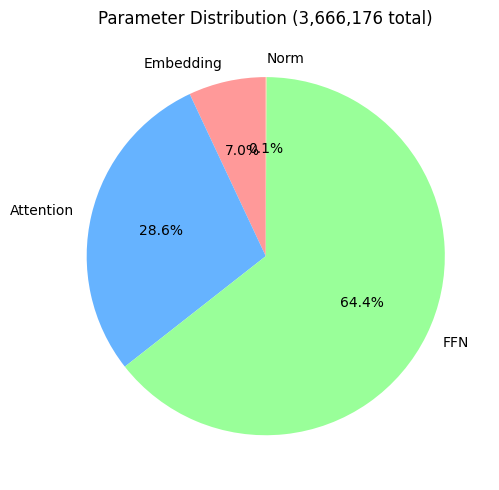

In [ ]:
def analyze_parameters(model, config):
    """Analyze parameter distribution in the model"""
    
    # Count by component
    embedding_params = model.tok_emb.weight.numel()
    
    # Per block
    block = model.blocks[0]
    attention_params = sum(p.numel() for p in block.attention.parameters())
    ffn_params = sum(p.numel() for p in block.ffn.parameters())
    norm_params = sum(p.numel() for p in block.ln1.parameters()) + sum(p.numel() for p in block.ln2.parameters())
    
    final_norm_params = sum(p.numel() for p in model.ln_f.parameters())
    # LM head shares weights with embedding (weight tying)
    
    total_attention = attention_params * config.n_layers
    total_ffn = ffn_params * config.n_layers
    total_norm = norm_params * config.n_layers + final_norm_params
    
    total_params, _ = model.count_parameters()
    
    print("Parameter Distribution:")
    print("=" * 50)
    print(f"  Token Embedding:    {embedding_params:>12,} ({embedding_params/total_params*100:5.1f}%)")
    print(f"  Attention (total):  {total_attention:>12,} ({total_attention/total_params*100:5.1f}%)")
    print(f"  FFN (total):        {total_ffn:>12,} ({total_ffn/total_params*100:5.1f}%)")
    print(f"  Normalization:      {total_norm:>12,} ({total_norm/total_params*100:5.1f}%)")
    print(f"  LM Head:            {'(tied)':>12}")
    print("=" * 50)
    print(f"  TOTAL:              {total_params:>12,}")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 5))
    
    labels = ['Embedding', 'Attention', 'FFN', 'Norm']
    sizes = [embedding_params, total_attention, total_ffn, total_norm]
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
    
    ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'Parameter Distribution ({total_params:,} total)', fontsize=12)
    plt.tight_layout()
    plt.show()


analyze_parameters(model, config)

---
## 7. Text Generation

The key feature of GPT: **autoregressive text generation**!

In [ ]:
@torch.no_grad()
def generate(
    model,
    input_ids,
    max_new_tokens=50,
    temperature=1.0,
    top_k=50,
    top_p=0.9,
    use_kv_cache=True
):
    """
    Generate text autoregressively.
    
    Args:
        model: GPT model
        input_ids: (batch, seq_len) starting tokens
        max_new_tokens: Number of tokens to generate
        temperature: Sampling temperature (higher = more random)
        top_k: Keep only top k tokens
        top_p: Nucleus sampling threshold
        use_kv_cache: Use KV caching for efficiency
    """
    model.eval()
    batch_size = input_ids.shape[0]
    
    generated = input_ids.clone()
    kv_caches = None
    
    for i in range(max_new_tokens):
        if use_kv_cache and kv_caches is not None:
            # Only feed the last token
            curr_input = generated[:, -1:]
            start_pos = generated.shape[1] - 1
        else:
            # Feed all tokens
            curr_input = generated
            start_pos = 0
            kv_caches = None
        
        # Forward pass
        logits, kv_caches = model(curr_input, start_pos=start_pos, kv_caches=kv_caches)
        
        # Get logits for last token only
        logits = logits[:, -1, :]  # (batch, vocab_size)
        
        # Apply temperature
        if temperature != 1.0:
            logits = logits / temperature
        
        # Top-k filtering
        if top_k > 0:
            top_k_values, _ = torch.topk(logits, top_k, dim=-1)
            threshold = top_k_values[:, -1:]
            logits = torch.where(logits < threshold, float('-inf'), logits)
        
        # Top-p (nucleus) filtering
        if top_p < 1.0:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
            probs = F.softmax(sorted_logits, dim=-1)
            cumulative_probs = torch.cumsum(probs, dim=-1)
            
            # Remove tokens with cumulative prob above threshold
            sorted_mask = cumulative_probs > top_p
            sorted_mask[:, 1:] = sorted_mask[:, :-1].clone()
            sorted_mask[:, 0] = False
            
            # Scatter mask back to original order
            mask = sorted_mask.scatter(1, sorted_indices, sorted_mask)
            logits = logits.masked_fill(mask, float('-inf'))
        
        # Sample from distribution
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        
        # Append to generated
        generated = torch.cat([generated, next_token], dim=1)
    
    return generated

In [ ]:
# Test generation (random model, so output will be gibberish)
model.eval()

# Start with some tokens
input_ids = torch.randint(0, config.vocab_size, (1, 5))
print(f"Input tokens: {input_ids[0].tolist()}")

# Generate
output = generate(model, input_ids, max_new_tokens=10, temperature=0.8)
print(f"Generated tokens: {output[0].tolist()}")
print(f"New tokens: {output[0, 5:].tolist()}")

Input tokens: [30, 971, 699, 396, 625]
Generated tokens: [30, 971, 699, 396, 625, 760, 56, 188, 201, 47, 105, 867, 173, 301, 173]
New tokens: [760, 56, 188, 201, 47, 105, 867, 173, 301, 173]


---
## 8. Training Loop (Basic)

Here's how GPT is trained with next-token prediction:

In [ ]:
def compute_loss(model, input_ids, target_ids):
    """
    Compute cross-entropy loss for next-token prediction.
    
    Args:
        model: GPT model
        input_ids: (batch, seq_len) input tokens
        target_ids: (batch, seq_len) target tokens (shifted by 1)
    """
    logits, _ = model(input_ids)
    
    # Reshape for cross entropy
    # logits: (batch, seq_len, vocab_size) -> (batch * seq_len, vocab_size)
    # targets: (batch, seq_len) -> (batch * seq_len)
    loss = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        target_ids.reshape(-1),
        ignore_index=-100  # Ignore padding tokens
    )
    
    return loss


# Simple training example
def train_step(model, optimizer, batch):
    """Single training step"""
    model.train()
    
    # Input is all tokens except last, target is all tokens except first
    input_ids = batch[:, :-1]
    target_ids = batch[:, 1:]
    
    optimizer.zero_grad()
    loss = compute_loss(model, input_ids, target_ids)
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [ ]:
# Quick training test
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# Fake batch of data
batch = torch.randint(0, config.vocab_size, (4, 32))  # (batch=4, seq_len=32)

# Train for a few steps
losses = []
for step in range(10):
    loss = train_step(model, optimizer, batch)
    losses.append(loss)
    
print(f"Training losses: {[f'{l:.4f}' for l in losses]}")
print(f"Loss decreased: {losses[-1] < losses[0]}")

Training losses: ['6.9351', '6.5978', '6.3663', '6.1911', '6.0466', '5.9179', '5.7959', '5.6773', '5.5605', '5.4429']
Loss decreased: True


---
## 9. KV Cache Visualization

Why KV caching is crucial for fast inference:

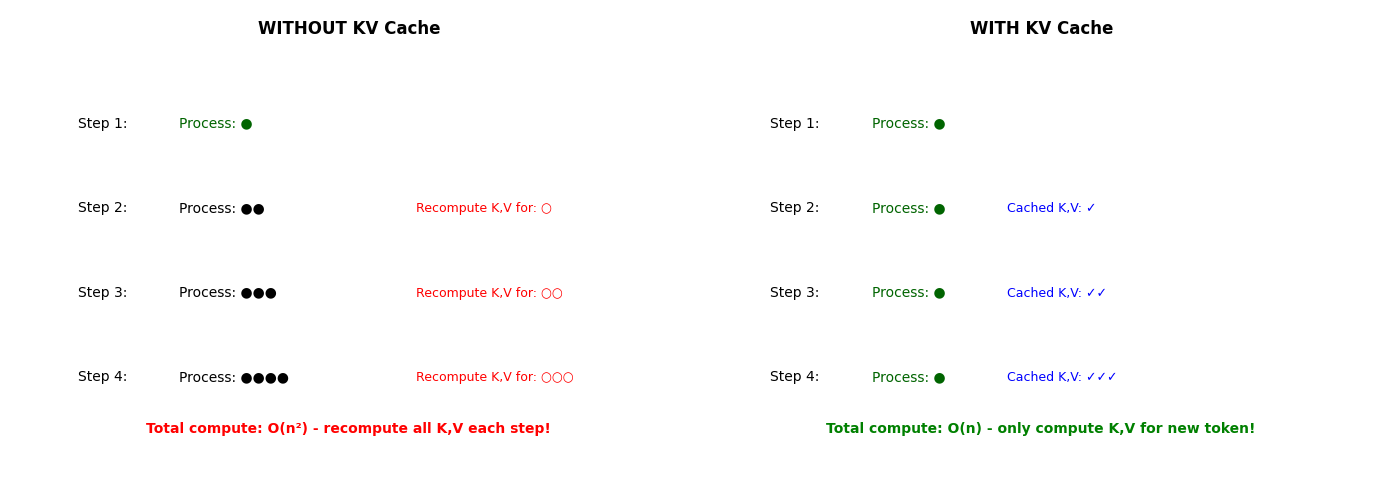


KV Cache Trade-off:
  ✅ Much faster generation (O(n) vs O(n²))
  ❌ Uses more memory (stores K,V for all tokens)
  📊 For 7B model, 2K context: ~1GB KV cache per batch item


In [ ]:
# Visualize KV cache benefit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Without KV cache
ax = axes[0]
ax.text(0.5, 0.95, 'WITHOUT KV Cache', ha='center', fontsize=12, fontweight='bold', transform=ax.transAxes)

for i, step in enumerate([1, 2, 3, 4]):
    y = 0.75 - i * 0.18
    # Show tokens being processed
    tokens = ''.join(['●' for _ in range(step)])
    recomputed = ''.join(['○' for _ in range(step-1)]) if step > 1 else ''
    ax.text(0.1, y, f'Step {step}:', fontsize=10, transform=ax.transAxes)
    ax.text(0.25, y, f'Process: {tokens}', fontsize=10, transform=ax.transAxes,
            color='darkgreen' if step == 1 else 'black')
    if step > 1:
        ax.text(0.6, y, f'Recompute K,V for: {recomputed}', fontsize=9, 
                color='red', transform=ax.transAxes)

ax.text(0.5, 0.1, 'Total compute: O(n²) - recompute all K,V each step!', 
        ha='center', fontsize=10, color='red', fontweight='bold', transform=ax.transAxes)
ax.axis('off')

# With KV cache
ax = axes[1]
ax.text(0.5, 0.95, 'WITH KV Cache', ha='center', fontsize=12, fontweight='bold', transform=ax.transAxes)

for i, step in enumerate([1, 2, 3, 4]):
    y = 0.75 - i * 0.18
    cached = ''.join(['✓' for _ in range(step-1)]) if step > 1 else ''
    ax.text(0.1, y, f'Step {step}:', fontsize=10, transform=ax.transAxes)
    ax.text(0.25, y, f'Process: ●', fontsize=10, transform=ax.transAxes, color='darkgreen')
    if step > 1:
        ax.text(0.45, y, f'Cached K,V: {cached}', fontsize=9, 
                color='blue', transform=ax.transAxes)

ax.text(0.5, 0.1, 'Total compute: O(n) - only compute K,V for new token!', 
        ha='center', fontsize=10, color='green', fontweight='bold', transform=ax.transAxes)
ax.axis('off')

plt.tight_layout()
plt.show()

print("\nKV Cache Trade-off:")
print("  ✅ Much faster generation (O(n) vs O(n²))")
print("  ❌ Uses more memory (stores K,V for all tokens)")
print("  📊 For 7B model, 2K context: ~1GB KV cache per batch item")

---
## 10. GPT Architecture Comparison

In [ ]:
comparison = """
┌─────────────────────────────────────────────────────────────────────────────────────┐
│                              GPT ARCHITECTURE VARIANTS                              │
├──────────────┬─────────┬──────────┬─────────┬───────────┬────────────────────────────┤
│    Model     │ d_model │ n_layers │ n_heads │  Params   │          Notes             │
├──────────────┼─────────┼──────────┼─────────┼───────────┼────────────────────────────┤
│  GPT-2 Small │   768   │    12    │   12    │   124M    │ Original OpenAI            │
│  GPT-2 Medium│  1024   │    24    │   16    │   350M    │                            │
│  GPT-2 Large │  1280   │    36    │   20    │   774M    │                            │
│  GPT-2 XL    │  1600   │    48    │   25    │   1.5B    │                            │
├──────────────┼─────────┼──────────┼─────────┼───────────┼────────────────────────────┤
│  GPT-3       │  12288  │    96    │   96    │   175B    │ API only                   │
├──────────────┼─────────┼──────────┼─────────┼───────────┼────────────────────────────┤
│  LLaMA 7B    │  4096   │    32    │   32    │    7B     │ + RoPE, SwiGLU, RMSNorm    │
│  LLaMA 13B   │  5120   │    40    │   40    │   13B     │                            │
│  LLaMA 70B   │  8192   │    80    │   64    │   70B     │ + GQA                      │
├──────────────┼─────────┼──────────┼─────────┼───────────┼────────────────────────────┤
│  Mistral 7B  │  4096   │    32    │   32    │    7B     │ + Sliding Window Attention │
└──────────────┴─────────┴──────────┴─────────┴───────────┴────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────┐
│                             GPT vs OLD TRANSFORMER                                  │
├───────────────────────────┬─────────────────────────────────────────────────────────┤
│      Original (2017)      │              Modern GPT (LLaMA style)                   │
├───────────────────────────┼─────────────────────────────────────────────────────────┤
│  Post-Norm                │  Pre-Norm (more stable)                                 │
│  LayerNorm                │  RMSNorm (faster)                                       │
│  Sinusoidal PE            │  RoPE (relative position)                               │
│  ReLU in FFN              │  SwiGLU (better quality)                                │
│  With bias                │  No bias (fewer params)                                 │
│  Learned pos embedding    │  Rotary (extrapolates)                                  │
└───────────────────────────┴─────────────────────────────────────────────────────────┘
"""
print(comparison)


┌─────────────────────────────────────────────────────────────────────────────────────┐
│                              GPT ARCHITECTURE VARIANTS                              │
├──────────────┬─────────┬──────────┬─────────┬───────────┬────────────────────────────┤
│    Model     │ d_model │ n_layers │ n_heads │  Params   │          Notes             │
├──────────────┼─────────┼──────────┼─────────┼───────────┼────────────────────────────┤
│  GPT-2 Small │   768   │    12    │   12    │   124M    │ Original OpenAI            │
│  GPT-2 Medium│  1024   │    24    │   16    │   350M    │                            │
│  GPT-2 Large │  1280   │    36    │   20    │   774M    │                            │
│  GPT-2 XL    │  1600   │    48    │   25    │   1.5B    │                            │
├──────────────┼─────────┼──────────┼─────────┼───────────┼────────────────────────────┤
│  GPT-3       │  12288  │    96    │   96    │   175B    │ API only                   │
├──────────────┼──────

---
## Exercises

### Exercise 1: Add Learned Position Embedding

Modify GPT to optionally use learned position embeddings instead of RoPE (like original GPT-2).

In [ ]:
# TODO: Create GPT variant with learned position embeddings
# Hint: Add nn.Embedding(max_seq_len, d_model) and add to token embeddings

class GPTWithLearnedPE(nn.Module):
    def __init__(self, config):
        super().__init__()
        # Your implementation here
        pass

### Exercise 2: Implement Greedy vs Sampling Generation

Compare greedy decoding (always pick most likely token) vs sampling.

In [ ]:
# TODO: Implement greedy generation (temperature=0, no sampling)
# Compare diversity of outputs with sampling

def generate_greedy(model, input_ids, max_new_tokens=50):
    # Your implementation here
    pass

### Exercise 3: Measure KV Cache Speedup

Benchmark generation with and without KV cache.

In [ ]:
# TODO: Time generation with use_kv_cache=True vs False
# How much faster is it?

import time

# Your benchmarking code here

---
## Summary

### What We Built

A complete **modern GPT model** (LLaMA-style) with:

1. **Token Embeddings** + **RoPE** (rotary position encoding)
2. **N Transformer Blocks**, each with:
   - Pre-Norm with RMSNorm
   - Causal Multi-Head Self-Attention
   - SwiGLU Feed-Forward Network
   - Residual connections
3. **Final RMSNorm** + **LM Head** (weight-tied with embedding)
4. **KV Caching** for efficient generation
5. **Sampling strategies**: temperature, top-k, top-p

### Key Insights

```
GPT Architecture:
├── Decoder-only (no encoder)
├── Causal masking (can't see future)
├── Autoregressive generation (one token at a time)
└── Pre-trained with next-token prediction

Modern Improvements (LLaMA vs GPT-2):
├── RoPE instead of learned position embedding
├── RMSNorm instead of LayerNorm
├── SwiGLU instead of GELU FFN
├── Pre-Norm instead of Post-Norm
└── No bias terms
```

### Next Up: BERT (Encoder Architecture)

How bidirectional models work for understanding tasks!